# LiDAR Ground Plane Estimation (nuScenes)

This notebook:
- Loads a `.bin` LiDAR point cloud from nuScenes
- Visualizes it
- Estimates the ground plane using RANSAC
- Computes the slope of the ground relative to the sensor


In [40]:
# Install dependencies
!pip install open3d numpy matplotlib

## Load nuScenes point cloud

Each point has format:
`[x, y, z, intensity, ring_index]`

We only use XYZ coordinates.

In [41]:
import numpy as np

def load_nuscenes_bin(file_path):
    points = np.fromfile(file_path, dtype=np.float32)
    points = points.reshape(-1, 5)
    xyz = points[:, :3]
    return xyz

# Update this path
file_path = r'C:\Users\Lars Wissink\OneDrive\Documenten\lars wissink\WB TU Delft\jaar 3\bep\pointcloud.bin'

points = load_nuscenes_bin(file_path)
print('Loaded points:', points.shape)

Loaded points: (34752, 3)


## Visualize lidar data

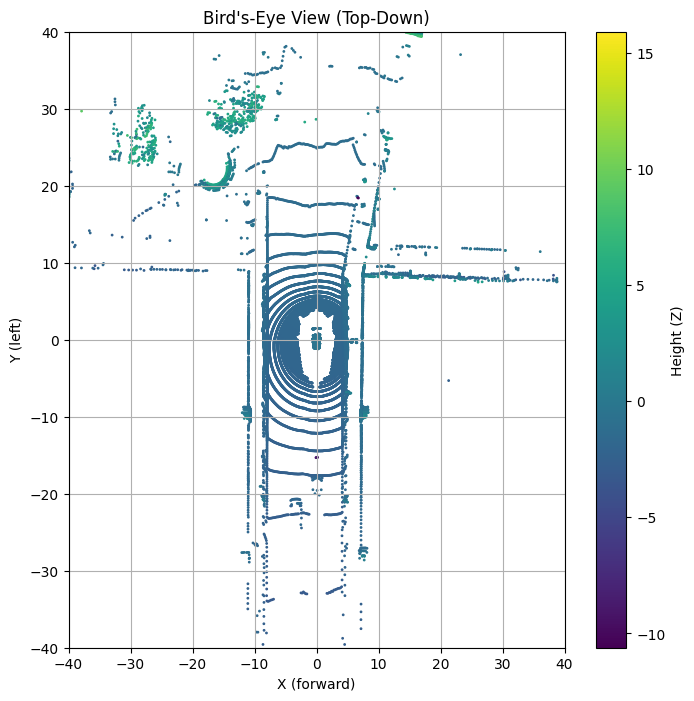

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_bev(points, max_points=100000):

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    plt.figure(figsize=(8, 8))

    scatter = plt.scatter(
        x, y,
        c=z,                # color by height
        s=1,                # point size
    )

    plt.colorbar(scatter, label="Height (Z)")

    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title("Bird's-Eye View (Top-Down)")

    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    plt.grid(True)

    plt.show()

visualize_bev(points)

## Estimate ground plane (RANSAC)

Fits a plane: ax + by + cz + d = 0

In [43]:
import open3d as o3d
import numpy as np

def estimate_ground_plane_bottom(points, bottom_fraction=0.2):
    """
    Estimate the ground plane using only the bottom fraction of points (by height).

    Args:
        points: Nx3 array of LiDAR points
        bottom_fraction: fraction of points (lowest Z) to use for plane fitting
    """
    # Select bottom fraction by Z
    z_threshold = np.percentile(points[:,2], bottom_fraction*100)
    bottom_points = points[points[:,2] <= z_threshold]

    print(f"Using {len(bottom_points)} points ({bottom_fraction*100:.0f}% lowest) for ground estimation.")

    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(bottom_points)

    # RANSAC plane fit
    plane_model, inliers = pcd.segment_plane(
        distance_threshold=0.2,
        ransac_n=3,
        num_iterations=1000
    )

    a, b, c, d = plane_model
    print(f'Plane equation: {a:.4f}x + {b:.4f}y + {c:.4f}z + {d:.4f} = 0')

    # Map inliers back to original points (optional)
    # Here, inliers are indices in bottom_points
    # You could convert to indices in full points if needed

    return plane_model, inliers, bottom_points

# Usage
plane_model, inliers, bottom_points = estimate_ground_plane_bottom(points, bottom_fraction=0.2)

Using 6951 points (20% lowest) for ground estimation.
Plane equation: -0.0088x + -0.0314y + 0.9995z + 1.8700 = 0


## Compute slope of ground plane

- Plane normal = (a, b, c)
- Compare with vertical axis (0,0,1)
- Output slope in degrees

In [44]:
import numpy as np

def compute_slope_fixed(plane_model):
    a, b, c, d = plane_model

    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)

    z_axis = np.array([0, 0, 1])

    # angle between normal and vertical
    angle_rad = np.arccos(np.clip(np.dot(normal, z_axis), -1.0, 1.0))
    angle_deg = np.degrees(angle_rad)

    slope_deg = angle_deg  # small tilt = small slope

    print(f'Angle between normal and vertical: {angle_deg:.2f}°')
    print(f'Ground slope: {slope_deg:.2f}°')

    return slope_deg

# Usage
slope = compute_slope_fixed(plane_model)

Angle between normal and vertical: 1.87°
Ground slope: 1.87°


# Visualize vertical distance to the ground plane

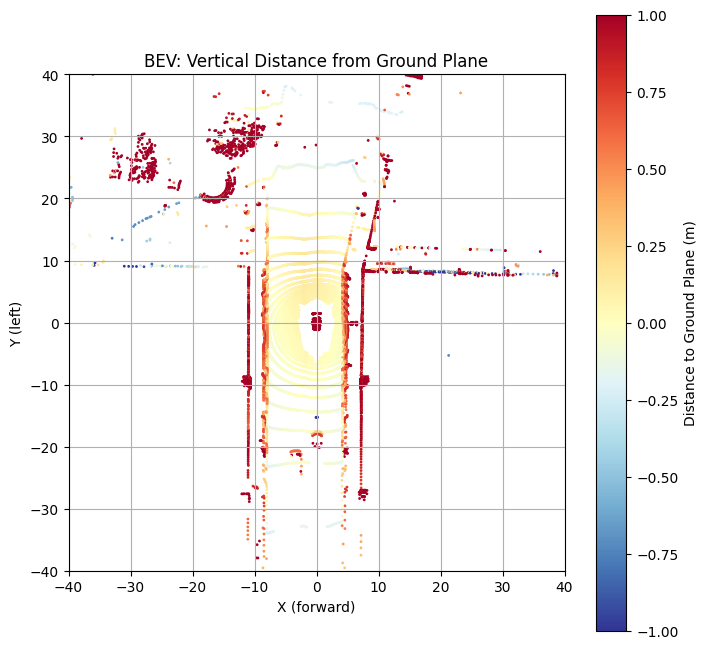

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_bev_distance(points, plane_model, max_points=100000, distance_clip=1.0):
    """
    BEV plot (X-Y) where color encodes vertical distance from the ground plane.

    Args:
        points: Nx3 LiDAR points
        plane_model: [a, b, c, d] plane coefficients
        max_points: maximum points to plot (for speed)
        distance_clip: max abs distance to visualize (m)
    """
    a, b, c, d = plane_model

    # Normalize plane
    norm = np.linalg.norm([a, b, c])
    a, b, c, d = a/norm, b/norm, c/norm, d/norm
    normal = np.array([a, b, c])

    # Signed vertical distance
    distances = points @ normal + d

    x = points[:,0]
    y = points[:,1]

    # Clip distances for visualization
    distances = np.clip(distances, -distance_clip, distance_clip)

    plt.figure(figsize=(8,8))

    sc = plt.scatter(
        x, y,
        c=distances,
        s=1,
        cmap='RdYlBu_r'  # red=above plane, blue=below
    )

    plt.colorbar(sc, label="Distance to Ground Plane (m)")
    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title("BEV: Vertical Distance from Ground Plane")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    plt.grid(True)
    plt.show()

# Usage
visualize_bev_distance(points, plane_model)

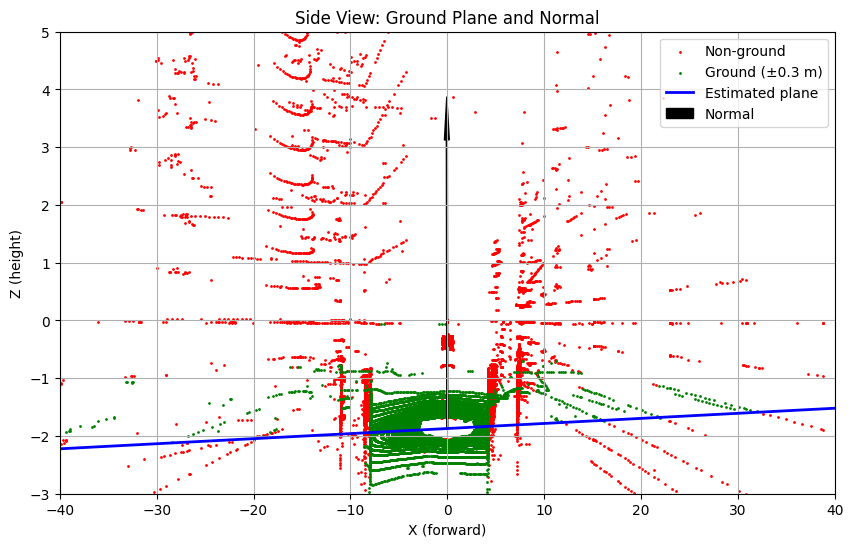

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_ground_plane_side(points, plane_model, distance_thresh=0.3):
    """
    Side view (X-Z) showing:
    - ground points (green)
    - other points (red)
    - estimated plane (blue line)
    - normal vector (black arrow)
    """

    a, b, c, d = plane_model

    # Normalize plane normal
    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)
    a, b, c = normal

    # Signed distance of each point to plane
    distances = points @ normal + d
    inliers = np.abs(distances) < distance_thresh

    x = points[:,0]
    z = points[:,2]

    plt.figure(figsize=(10,6))

    # Plot points
    plt.scatter(x[~inliers], z[~inliers], s=1, color='red', label='Non-ground')
    plt.scatter(x[inliers], z[inliers], s=1, color='green', label=f'Ground (±{distance_thresh} m)')

    # Plane line (Y≈0 slice)
    xs = np.linspace(-40, 40, 500)
    zs = (-a*xs - d)/c
    plt.plot(xs, zs, color='blue', linewidth=2, label='Estimated plane')

    # Normal vector from point on plane at x=0, y=0
    origin = np.array([0, 0, -d/c])
    scale = 5
    normal_end = origin + normal * scale
    plt.arrow(
        origin[0], origin[2],
        normal[0]*scale, normal[2]*scale,
        color='black', width=0.1, head_width=0.5,
        label='Normal'
    )

    plt.xlabel("X (forward)")
    plt.ylabel("Z (height)")
    plt.title("Side View: Ground Plane and Normal")
    plt.xlim(-40, 40)
    plt.ylim(-3, 5)
    plt.grid(True)
    plt.legend()
    plt.show()

# Usage
visualize_ground_plane_side(points, plane_model)

# Grid-based Ground Curvature Estimation

Divides the point cloud into a grid of cells. For each cell:
- Selects points near the reference ground plane
- Fits a local plane using RANSAC
- Computes the local slope relative to vertical

The result is a curvature map showing how the ground tilts across the scene.

In [47]:

def compute_grid_slopes(points, plane_model, grid_size=5.0, distance_thresh=0.5, min_points=10):
    """
    Divide the point cloud into grid cells, fit a local plane per cell,
    and compute slope relative to vertical.

    Args:
        points:          Nx3 LiDAR points
        plane_model:     reference plane [a, b, c, d] (used to isolate ground points)
        grid_size:       width/height of each grid cell in meters
        distance_thresh: max distance from reference plane to be considered ground
        min_points:      minimum points required to fit a plane in a cell
    Returns:
        list of (cx, cy, slope_deg, normal_xy) per grid cell
    """
    a, b, c, d = plane_model
    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)

    # Keep only points close to the reference ground plane
    distances = points @ normal + d
    ground_points = points[np.abs(distances) < distance_thresh]
    print(f"Ground points used for grid fitting: {len(ground_points)}")

    x_min, x_max = ground_points[:, 0].min(), ground_points[:, 0].max()
    y_min, y_max = ground_points[:, 1].min(), ground_points[:, 1].max()

    x_bins = np.arange(x_min, x_max + grid_size, grid_size)
    y_bins = np.arange(y_min, y_max + grid_size, grid_size)

    z_axis = np.array([0, 0, 1])
    results = []

    for i in range(len(x_bins) - 1):
        for j in range(len(y_bins) - 1):
            mask = (
                (ground_points[:, 0] >= x_bins[i]) & (ground_points[:, 0] < x_bins[i+1]) &
                (ground_points[:, 1] >= y_bins[j]) & (ground_points[:, 1] < y_bins[j+1])
            )
            cell_pts = ground_points[mask]

            if len(cell_pts) < min_points:
                continue

            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(cell_pts)

            try:
                local_plane, _ = pcd.segment_plane(
                    distance_threshold=0.1,
                    ransac_n=3,
                    num_iterations=100
                )
                la, lb, lc, ld = local_plane
                local_normal = np.array([la, lb, lc])
                local_normal = local_normal / np.linalg.norm(local_normal)

                slope = np.degrees(np.arccos(np.clip(np.dot(local_normal, z_axis), -1, 1)))

                # XY component of the normal = direction the plane tilts
                tilt_xy = local_normal[:2]
                tilt_magnitude = np.linalg.norm(tilt_xy)
                tilt_dir = tilt_xy / tilt_magnitude if tilt_magnitude > 1e-6 else np.array([0, 0])

                cx = (x_bins[i] + x_bins[i+1]) / 2
                cy = (y_bins[j] + y_bins[j+1]) / 2
                results.append((cx, cy, slope, tilt_dir, tilt_magnitude))
            except Exception:
                continue

    return results


def visualize_curvature_map(results, grid_size=5.0):
    """
    Plot a heatmap of local ground slope per grid cell, with:
    - arrows showing the tilt direction of each local plane
    - sensor location marker at the origin
    - sensor forward (+X) and left (+Y) direction arrows
    """
    if not results:
        print("No cells with enough points to fit a plane.")
        return

    xs     = np.array([r[0] for r in results])
    ys     = np.array([r[1] for r in results])
    slopes = np.array([r[2] for r in results])
    dirs   = np.array([r[3] for r in results])   # unit tilt direction (XY)
    mags   = np.array([r[4] for r in results])   # tilt magnitude

    vmax = np.percentile(slopes, 95)
    arrow_scale = grid_size * 0.45  # arrow length relative to cell size

    fig, ax = plt.subplots(figsize=(11, 10))

    # --- grid cell slope heatmap ---
    sc = ax.scatter(
        xs, ys,
        c=slopes,
        cmap='RdYlGn_r',
        s=(grid_size * 9) ** 2,
        marker='s',
        vmin=0, vmax=vmax,
        zorder=1
    )
    plt.colorbar(sc, ax=ax, label='Local slope (degrees)')

    # --- tilt direction arrows per cell ---
    for i in range(len(xs)):
        if mags[i] > 1e-6:
            ax.annotate(
                '', 
                xy=(xs[i] + dirs[i, 0] * arrow_scale, ys[i] + dirs[i, 1] * arrow_scale),
                xytext=(xs[i], ys[i]),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                zorder=3
            )

    # --- sensor location dot ---
    ax.plot(0, 0, 'o', color='dodgerblue', markersize=10, zorder=5, label='Sensor location')

    # --- sensor orientation arrows ---
    sensor_arrow_len = grid_size * 1.5
    ax.annotate(
        'Forward (+X)',
        xy=(sensor_arrow_len, 0), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=2.5),
        fontsize=9, color='dodgerblue', zorder=5,
        xycoords='data', textcoords='data',
        ha='left', va='bottom'
    )
    ax.annotate(
        'Left (+Y)',
        xy=(0, sensor_arrow_len), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.5),
        fontsize=9, color='darkorange', zorder=5,
        xycoords='data', textcoords='data',
        ha='left', va='bottom'
    )

    ax.set_xlabel('X (forward, m)')
    ax.set_ylabel('Y (left, m)')
    ax.set_title(f'Ground Curvature Map  (grid cell = {grid_size} m)\nBlack arrows = tilt direction of local plane')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='upper right')
    ax.grid(True, linewidth=0.4)
    plt.tight_layout()
    plt.show()

    print(f"\nSlope statistics across {len(slopes)} cells:")
    print(f"  Min:  {slopes.min():.2f} deg")
    print(f"  Max:  {slopes.max():.2f} deg")
    print(f"  Mean: {slopes.mean():.2f} deg")
    print(f"  Std:  {slopes.std():.2f} deg")


Ground points used for grid fitting: 18691
Fitted local planes in 296 grid cells


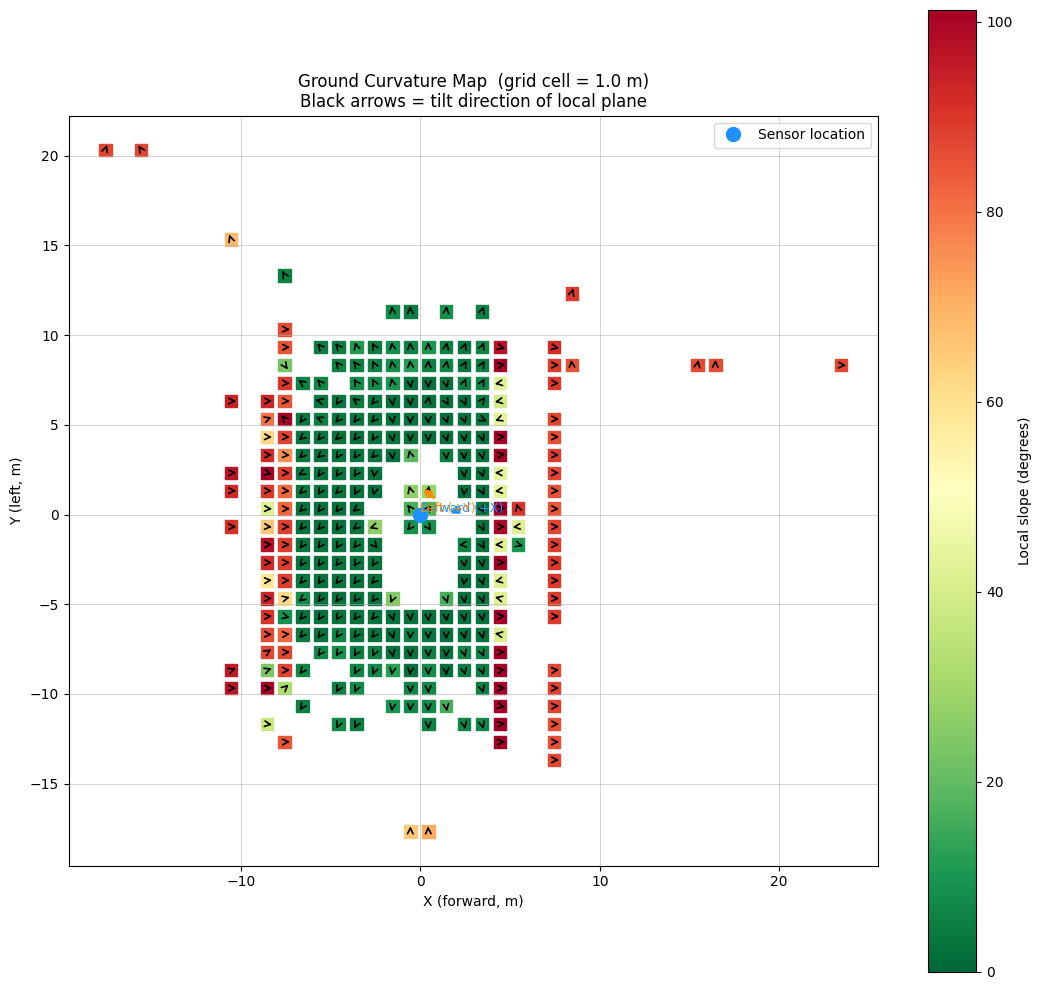


Slope statistics across 296 cells:
  Min:  1.36 deg
  Max:  133.45 deg
  Mean: 32.17 deg
  Std:  40.84 deg


In [48]:
# --- parameters ---
GRID_SIZE       = 1.0   # meters per cell (try 2.5 for finer detail)
DIST_THRESH     = 1.5   # max distance from reference plane to count as ground
MIN_POINTS_CELL = 15    # minimum points needed to fit a plane in a cell

grid_results = compute_grid_slopes(
    points, plane_model,
    grid_size=GRID_SIZE,
    distance_thresh=DIST_THRESH,
    min_points=MIN_POINTS_CELL
)

print(f"Fitted local planes in {len(grid_results)} grid cells")
visualize_curvature_map(grid_results, grid_size=GRID_SIZE)


In [49]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

def compute_polar_grid_slopes(points, plane_model, r_step=5.0, theta_step_deg=15.0, 
                              distance_thresh=0.5, min_points=10):
    """
    Divide point cloud into polar 'wedges', fit local planes, and compute slopes.
    """
    a, b, c, d = plane_model
    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)

    # 1. Isolate ground points
    distances = points @ normal + d
    ground_points = points[np.abs(distances) < distance_thresh]
    
    # 2. Convert to Polar
    x = ground_points[:, 0]
    y = ground_points[:, 1]
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x) # Result in radians [-pi, pi]

    # Define bins
    r_bins = np.arange(0, r.max() + r_step, r_step)
    theta_bins = np.deg2rad(np.arange(-180, 180 + theta_step_deg, theta_step_deg))

    z_axis = np.array([0, 0, 1])
    results = []

    # 3. Iterate through polar cells
    for i in range(len(r_bins) - 1):
        for j in range(len(theta_bins) - 1):
            mask = (
                (r >= r_bins[i]) & (r < r_bins[i+1]) &
                (theta >= theta_bins[j]) & (theta < theta_bins[j+1])
            )
            cell_pts = ground_points[mask]

            if len(cell_pts) < min_points:
                continue

            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(cell_pts)

            try:
                local_plane, _ = pcd.segment_plane(0.1, 3, 100)
                la, lb, lc, _ = local_plane
                l_norm = np.array([la, lb, lc])
                l_norm /= np.linalg.norm(l_norm)

                # Ensure normal points 'up'
                if l_norm[2] < 0: l_norm = -l_norm

                slope = np.degrees(np.arccos(np.clip(np.dot(l_norm, z_axis), -1, 1)))
                
                # Store geometry for plotting
                results.append({
                    'r_mid': (r_bins[i] + r_bins[i+1]) / 2,
                    'theta_mid': (theta_bins[j] + theta_bins[j+1]) / 2,
                    'r_bounds': (r_bins[i], r_bins[i+1]),
                    'theta_bounds': (theta_bins[j], theta_bins[j+1]),
                    'slope': slope,
                    'normal': l_norm
                })
            except:
                continue
    return results

def visualize_polar_curvature(results, r_step, theta_step_deg):
    if not results: return

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')

    # Extract data
    slopes = np.array([res['slope'] for res in results])
    vmax = np.percentile(slopes, 95)
    cmap = plt.get_cmap('RdYlGn_r')

    # 4. Draw Annular Sectors
    for res in results:
        r0, r1 = res['r_bounds']
        t0, t1 = res['theta_bounds']
        
        # Draw the filled wedge
        ax.bar(t0, r1-r0, width=t1-t0, bottom=r0, 
               color=cmap(res['slope']/vmax), align='edge', alpha=0.8)

    # 5. Add orientation markers
    ax.set_theta_zero_location('N') # Set 0° (Forward/X) to North
    ax.set_theta_direction(-1)      # Clockwise
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
    plt.colorbar(sm, ax=ax, label='Slope (degrees)')
    plt.title("Polar Ground Curvature Map")
    plt.show()

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d

def visualize_polar_curvature(results, r_step):
    """
    Plots the polar grid results. 
    Ensure this name matches the one you call below!
    """
    if not results:
        print("No results to plot.")
        return

    slopes = np.array([res['slope'] for res in results])
    # Normalize color mapping to the 95th percentile to avoid outliers ruining the contrast
    vmax = np.percentile(slopes, 95) if len(slopes) > 1 else slopes.max()
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    # Standard LiDAR orientation: North (0) is Forward (+X)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1) 

    cmap = plt.get_cmap('RdYlGn_r')

    for res in results:
        r0, r1 = res['r_bounds']
        t0, t1 = res['theta_bounds']
        
        # Draw the annular sector (the 'wedge')
        ax.bar(t0, r1-r0, width=t1-t0, bottom=r0, 
               color=cmap(res['slope']/vmax if vmax > 0 else 0), 
               align='edge', edgecolor='black', linewidth=0.2, alpha=0.8)

    # Colorbar and labels
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
    plt.colorbar(sm, ax=ax, label='Slope (degrees)')
    ax.set_title(f"Polar Ground Curvature Map\nRing size: {r_step}m", pad=20)
    plt.show()

# --- Execution ---
R_STEP = 2.0
# Call the function with the EXACT name defined above
#visualize_polar_curvature(polar_results, R_STEP)

Fitted local planes in 229 polar cells


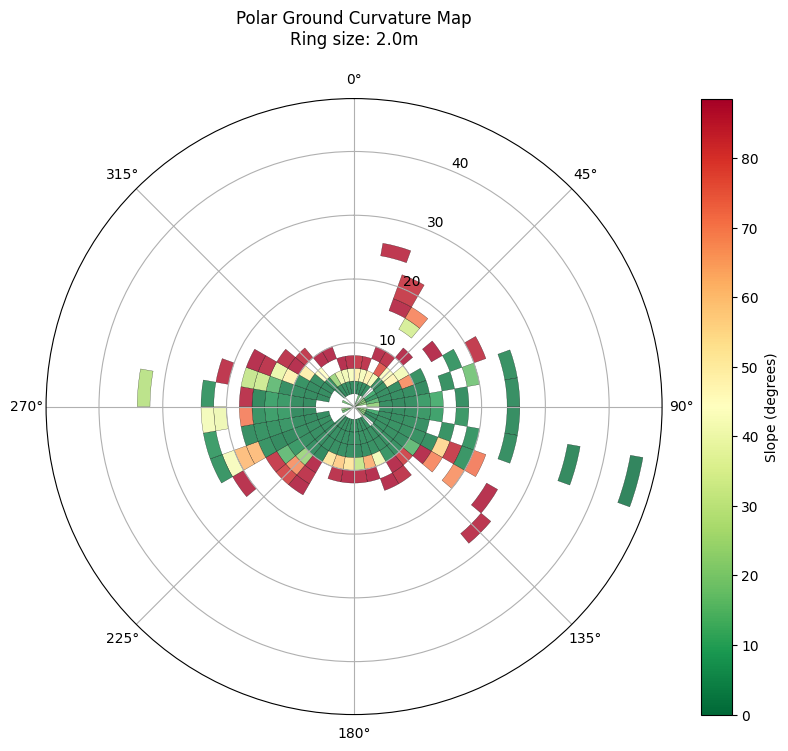

In [51]:

# --- Parameters ---
R_STEP          = 2.0   # Meters per radial "ring"
THETA_STEP      = 10.0  # Degrees per angular "wedge"
DIST_THRESH     = 1.5   # Max distance from reference plane
MIN_POINTS_CELL = 15    # Minimum points to fit a plane

# 1. Compute the slopes using the polar logic
polar_results = compute_polar_grid_slopes(
    points, 
    plane_model,
    r_step=R_STEP, 
    theta_step_deg=THETA_STEP,
    distance_thresh=DIST_THRESH, 
    min_points=MIN_POINTS_CELL
)

print(f"Fitted local planes in {len(polar_results)} polar cells")

# 2. Visualize using the polar projection
visualize_polar_curvature(polar_results, R_STEP)


In [52]:
%pip install pandas
import pandas as pd
import numpy as np

def compute_curvature_table(results):
    """
    Computes the angle difference between consecutive planes along the same radial line.
    """
    # 1. Organize data into a lookup dictionary: {(r_idx, theta_idx): normal}
    # We use indices to ensure we are looking at "neighbors"
    data_map = {}
    r_vals = sorted(list(set(res['r_bounds'][0] for res in results)))
    t_vals = sorted(list(set(res['theta_bounds'][0] for res in results)))
    
    # Map start values to indices for easy neighbor lookup
    r_map = {val: i for i, val in enumerate(r_vals)}
    t_map = {val: i for i, val in enumerate(t_vals)}
    
    for res in results:
        ridx = r_map[res['r_bounds'][0]]
        tidx = t_map[res['theta_bounds'][0]]
        data_map[(ridx, tidx)] = res['normal']

    # 2. Compare neighbors along the same theta
    # rows = radial transitions (e.g., "0m to 5m"), cols = angles
    table_data = []
    
    for i in range(len(r_vals) - 1):
        row_label = f"{r_vals[i]:.1f}m -> {r_vals[i+1]:.1f}m"
        row_dict = {"Radial Transition": row_label}
        
        for j, t_start in enumerate(t_vals):
            t_deg = np.degrees(t_start)
            col_label = f"{t_deg:.0f}°"
            
            n1 = data_map.get((i, j))
            n2 = data_map.get((i+1, j))
            
            if n1 is not None and n2 is not None:
                # Calculate angle between normals in degrees
                dot = np.clip(np.dot(n1, n2), -1.0, 1.0)
                diff = np.degrees(np.arccos(dot))
                row_dict[col_label] = round(diff, 2)
            else:
                row_dict[col_label] = np.nan # Missing data
                
        table_data.append(row_dict)

    return pd.DataFrame(table_data)

# --- Execution ---
curvature_df = compute_curvature_table(polar_results)

# Display the first few columns/rows
print("Curvature Table (Angle difference between consecutive radial planes):")
print(curvature_df.head())

# Optional: Export to CSV to inspect in Excel
# curvature_df.to_csv("ground_curvature.csv", index=False)



Curvature Table (Angle difference between consecutive radial planes):
  Radial Transition   -180°   -170°  -160°  -150°  -140°  -130°  -120°  -110°  \
0      0.0m -> 2.0m     NaN     NaN    NaN    NaN    NaN    NaN    NaN    NaN   
1      2.0m -> 4.0m    0.60    0.32   0.31   0.68   0.53    NaN    NaN    NaN   
2      4.0m -> 6.0m    2.71    0.21   0.21   0.13   0.07   0.13   0.36   0.86   
3      6.0m -> 8.0m   52.09   59.84  53.72   2.50   0.26   0.02   0.16   1.15   
4     8.0m -> 10.0m  141.57  145.55    NaN  88.32  25.55   2.41   1.25   1.91   

   -100°  ...    80°   90°   100°   110°   120°   130°   140°   150°    160°  \
0    NaN  ...    NaN   NaN  11.46  22.54  19.64    NaN    NaN    NaN     NaN   
1    NaN  ...  24.58   NaN  11.71   2.11   0.61    NaN   1.20   0.30    0.11   
2    NaN  ...   0.54  0.50   0.64   0.60   0.44   0.31   0.20   0.27    0.44   
3   0.19  ...   0.75  0.49   1.41   0.41   0.29   0.26   3.82  42.93   65.50   
4   3.71  ...   8.31  7.18   0.81   0.35  

Note: you may need to restart the kernel to use updated packages.


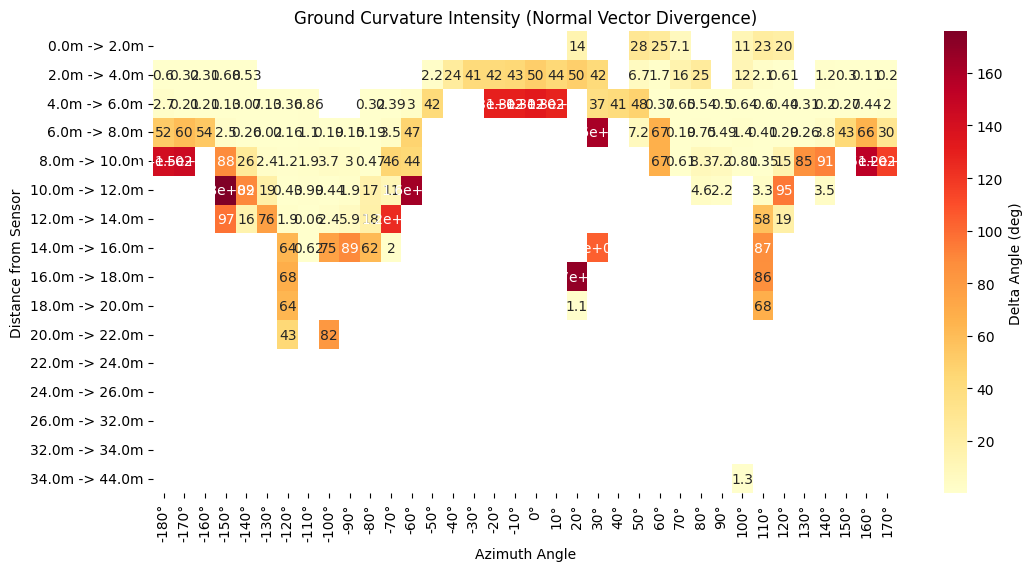

In [53]:
%pip install seaborn
import seaborn as sns

plt.figure(figsize=(12, 6))
# Remove the label column for the heatmap
sns.heatmap(curvature_df.set_index("Radial Transition").astype(float), 
            annot=True, cmap="YlOrRd", cbar_kws={'label': 'Delta Angle (deg)'})
plt.title("Ground Curvature Intensity (Normal Vector Divergence)")
plt.xlabel("Azimuth Angle")
plt.ylabel("Distance from Sensor")
plt.show()

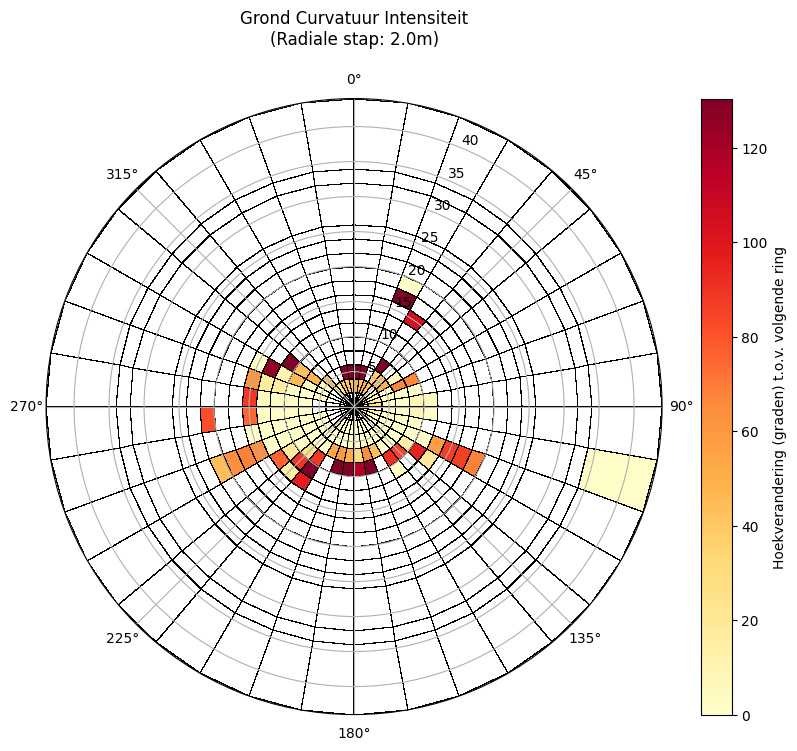

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def plot_direct_polar_curvature(results, r_step):
    """
    Berekent de hoekverandering tussen opeenvolgende ringen en 
    geeft dit weer in een polaire hittekaart (zoals je afbeelding).
    """
    if not results:
        print("Geen resultaten gevonden.")
        return

    # 1. Data organiseren voor snelle lookup
    r_starts = sorted(list(set(res['r_bounds'][0] for res in results)))
    t_starts = sorted(list(set(res['theta_bounds'][0] for res in results)))
    t_ends = sorted(list(set(res['theta_bounds'][1] for res in results)))
    
    # Maak een map: (r_waarde, t_waarde) -> normaalvector
    data_map = {(res['r_bounds'][0], res['theta_bounds'][0]): res['normal'] for res in results}

    # 2. Curvatuur matrix opbouwen (Verschil tussen ring i en i+1)
    # We hebben (N-1) rijen aan data voor N ringen
    num_r = len(r_starts)
    num_t = len(t_starts)
    curvature_matrix = np.full((num_r - 1, num_t), np.nan)

    for i in range(num_r - 1):
        r_curr = r_starts[i]
        r_next = r_starts[i+1]
        for j in range(num_t):
            t_curr = t_starts[j]
            
            n1 = data_map.get((r_curr, t_curr))
            n2 = data_map.get((r_next, t_curr))
            
            if n1 is not None and n2 is not None:
                # Bereken hoekverschil in graden
                dot = np.clip(np.dot(n1, n2), -1.0, 1.0)
                curvature_matrix[i, j] = np.degrees(np.arccos(dot))

    # 3. Plotten in Polair formaat
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    # Oriëntatie: 0 graden is Vooruit (+X)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # Definieer de grenzen voor de vakjes (edges)
    # Theta grenzen: alle startpunten + het allerlaatste eindpunt
    t_boundaries = np.array(t_starts + [t_ends[-1]])
    # R grenzen: we gebruiken de eerste (N-1) ringen omdat we daar curvatuur voor hebben
    r_boundaries = np.array(r_starts)

    # De hittekaart tekenen
    mesh = ax.pcolormesh(t_boundaries, r_boundaries, curvature_matrix, 
                         cmap='YlOrRd', shading='flat', edgecolor='black', linewidth=0.1)
    
    # Kleurenschaal instellen (automatisch op 95e percentiel voor goed contrast)
    valid_vals = curvature_matrix[~np.isnan(curvature_matrix)]
    if len(valid_vals) > 0:
        vmax = np.percentile(valid_vals, 95)
        mesh.set_clim(0, max(vmax, 2.0)) # Minimaal 2 graden schaal voor leesbaarheid

    plt.colorbar(mesh, ax=ax, label='Hoekverandering (graden) t.o.v. volgende ring')
    ax.set_title(f"Grond Curvatuur Intensiteit\n(Radiale stap: {r_step}m)", pad=20)
    plt.show()

# --- Uitvoeren ---
# Gebruik de resultaten uit je eerdere polar_results berekening
plot_direct_polar_curvature(polar_results, R_STEP)

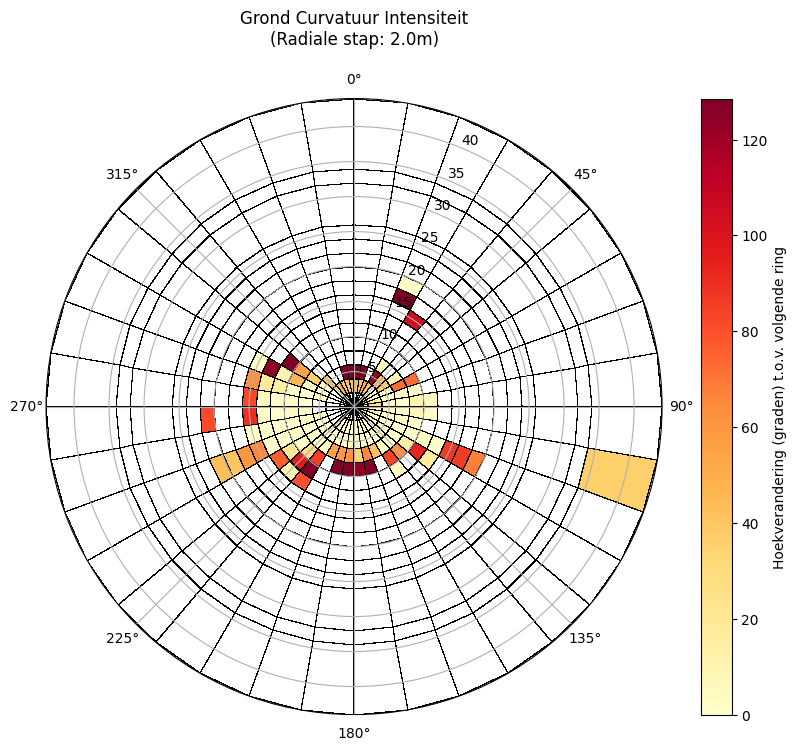

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_direct_polar_curvature(results, r_step):
    """
    Berekent de hoekverandering tussen opeenvolgende ringen en 
    geeft dit weer in een polaire hittekaart (zoals je afbeelding).
    """
    if not results:
        print("Geen resultaten gevonden.")
        return

    # 1. Data organiseren voor snelle lookup
    r_starts = sorted(list(set(res['r_bounds'][0] for res in results)))
    t_starts = sorted(list(set(res['theta_bounds'][0] for res in results)))
    t_ends = sorted(list(set(res['theta_bounds'][1] for res in results)))
    
    # Maak een map: (r_waarde, t_waarde) -> normaalvector
    data_map = {(res['r_bounds'][0], res['theta_bounds'][0]): res['normal'] for res in results}

    # 2. Curvatuur matrix opbouwen (Verschil tussen ring i en i+1)
    # We hebben (N-1) rijen aan data voor N ringen
    num_r = len(r_starts)
    num_t = len(t_starts)
    curvature_matrix = np.full((num_r - 1, num_t), np.nan)

    for i in range(num_r - 1):
        r_curr = r_starts[i]
        r_next = r_starts[i+1]
        for j in range(num_t):
            t_curr = t_starts[j]
            
            n1 = data_map.get((r_curr, t_curr))
            n2 = data_map.get((r_next, t_curr))
            
            if n1 is not None and n2 is not None:
                # Bereken hoekverschil in graden
                dot = np.clip(np.dot(n1, n2), -1.0, 1.0)
                curvature_matrix[i, j] = np.degrees(np.arccos(dot))

    # 3. Plotten in Polair formaat
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    # Oriëntatie: 0 graden is Vooruit (+X)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # Definieer de grenzen voor de vakjes (edges)
    # Theta grenzen: alle startpunten + het allerlaatste eindpunt
    t_boundaries = np.array(t_starts + [t_ends[-1]])
    # R grenzen: we gebruiken de eerste (N-1) ringen omdat we daar curvatuur voor hebben
    r_boundaries = np.array(r_starts)

    # De hittekaart tekenen
    mesh = ax.pcolormesh(t_boundaries, r_boundaries, curvature_matrix, 
                         cmap='YlOrRd', shading='flat', edgecolor='black', linewidth=0.1)
    
    # Kleurenschaal instellen (automatisch op 95e percentiel voor goed contrast)
    valid_vals = curvature_matrix[~np.isnan(curvature_matrix)]
    if len(valid_vals) > 0:
        vmax = np.percentile(valid_vals, 95)
        mesh.set_clim(0, max(vmax, 2.0)) # Minimaal 2 graden schaal voor leesbaarheid

    plt.colorbar(mesh, ax=ax, label='Hoekverandering (graden) t.o.v. volgende ring')
    ax.set_title(f"Grond Curvatuur Intensiteit\n(Radiale stap: {r_step}m)", pad=20)
    plt.show()

# --- Uitvoeren ---
# Gebruik de resultaten uit je eerdere polar_results berekening
plot_direct_polar_curvature(polar_results, R_STEP)